# Figures for thesis

### MZT

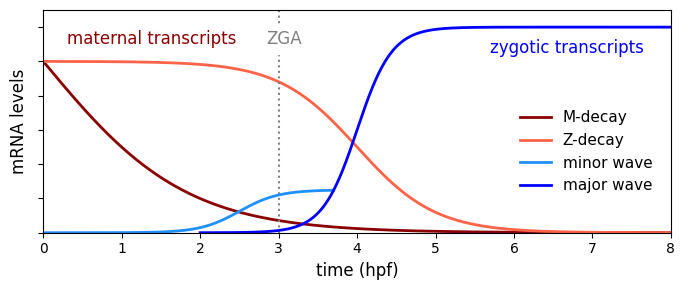

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import jax

t = np.linspace(0, 8, 1001)

M1 = jax.nn.sigmoid(-1.1 * t) 
M2 = jax.nn.sigmoid(-1.5 * (t-3))
M3 = jax.nn.sigmoid(-2 * (t-4))

t1 = np.linspace(0, 3.7, 1001)
t2 = np.linspace(2, 8, 1001)
Z1 = jax.nn.sigmoid(4* (t1-2.5)) 
Z2 = jax.nn.sigmoid(4.5* (t2-4)) 

fig, ax = plt.subplots(1,1, figsize=(7,3))

ax.plot(t, M1/M1.max(), c="darkred", lw=2, label="M-decay")
#ax.plot(t, M2/M2.max(), c="r", lw=2, label="during ZGA")
ax.plot(t, M3/M3.max(), c="tomato", lw=2, label="Z-decay")

ax.axvline(x=3, ls=":", color="grey")

ax.plot(t1, Z1/4, c="dodgerblue", lw=2, label="minor wave")
ax.plot(t2, Z2*1.2, c="blue", lw=2, label="major wave")

ax.text(0.3, 1.1, "maternal transcripts", color="darkred",  fontsize=12)
ax.text(5.7, 1.05, "zygotic transcripts", color="blue", fontsize=12)
ax.text(2.84, 1.1, "ZGA", color="grey", fontsize=12, backgroundcolor="white")

ax.set_xlabel("time (hpf)", fontsize=12) 
ax.set_ylabel("mRNA levels", fontsize=12)
#ax.set(title="Maternal-to-zygotic transition",)
ax.set(ylim=(0,1.3), xlim=(0,8))
ax.set_yticklabels("")
ax.legend(frameon=False, loc=(0.75, 0.15), fontsize=11)
plt.tight_layout()
plt.savefig("mzt_modes.png", dpi=300, transparent=True)

### Repression model

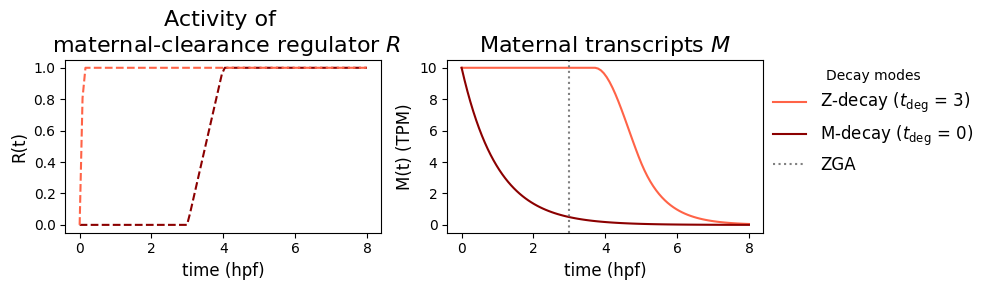

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

def zga(t, M0,  x_in, x_in_time, beta, delta_r, delta_z, t_zga):
    """
    ODE:
        dM/dt = - delta_m * M
        dZ/dt = beta - delta_z * Z, Z(0)=Z(t_zga)=0
    beta(t):
        0       if t < 3
        beta    if t >= 3
    """

    #maternal = M0 * jnp.exp(-delta_m * t)

    R_t = np.interp(t, x_in_time, x_in)
    #M = M0 * jnp.exp(-(delta_m + delta_r * R_t) * t)
    dt = np.diff(t, prepend=0.0)
    exp_term = np.cumsum((delta_r * R_t) * dt)
    M = M0 * np.exp(-exp_term)

    Z = np.where(t > t_zga, beta/delta_z * ( 1 - np.exp(-delta_z * (t-t_zga))), 0.0)
    total = M+Z
    return M, Z, total

def zga_m(t, M0,  beta, delta_m, delta_z, t_zga):

    # dM/dt = - d * M -> - d* 1 / ()
    M = M0 * np.exp(-delta_m *t)

    Z = np.where(t > t_zga, beta/delta_z * ( 1 - np.exp(-delta_z * (t-t_zga))), 0.0)
    total = M+Z
    return M, Z, total

def regulator_activity(t, t_on, t_off=4.0):
    t = np.asarray(t)
    slope = 1/(t_off - t_on)
    return np.where(t <= t_on, 0.0,
            np.where(t <= t_off, slope * (t - t_on), 1.0))

M0 = 10
delta_m = 0.0
delta_z = 0.1
#delta_r = 0.2
t_zga = 3
t = np.linspace(0, 48, 100)

from matplotlib import colormaps
colors = colormaps['turbo'].resampled(7)

fig, (ax1, ax) = plt.subplots(1,2, figsize=(10, 3))
beta = 1.0
t_zga = 3
delta_r = 1.4
t = np.linspace(0, 8, 100)
x_in = regulator_activity(t, 3, 4)
x_in_M = regulator_activity(t, 0, .1)
x_in_time = np.linspace(0, 10, 100)
M, Z, T  = zga(t, M0, x_in, x_in_time, beta, delta_r, delta_z, t_zga)
ax.plot(t, M,  ls="-", c="tomato",  label=f"Z-decay ($t_{{\\text{{deg}}}}$ = 3)")

delta_m = 1
M, Z, T  = zga_m(t, M0, beta, delta_m, delta_z, t_zga)
ax.plot(t, M,  ls="-", c="darkred",  label=f"M-decay ($t_{{\\text{{deg}}}}$ = 0)")
ax.axvline(x=3, ls=":", color="grey", label="ZGA")

#ax.legend(frameon=False)
ax.set_title(f"Maternal transcripts $M$", fontsize=16)
ax.set_xlabel("time (hpf)", fontsize=12) 
ax.set_ylabel("M(t) (TPM)", fontsize=12)
#plt.tight_layout()
#plt.savefig("figures/decay_modes.png", dpi=300)

ax1.plot(t, x_in, c="darkred", ls="--")
ax1.plot(t, x_in_M, c="tomato", ls="--")

ax1.set_title("Activity of \n maternal-clearance regulator $R$", fontsize=16)
ax1.set_xlabel("time (hpf)", fontsize=12) 
ax1.set_ylabel("R(t)", fontsize=12)
ax.legend(title="Decay modes", loc=(1.01, 0.3), frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig("reg_activity_decay_modes.png", dpi=300, transparent=True)

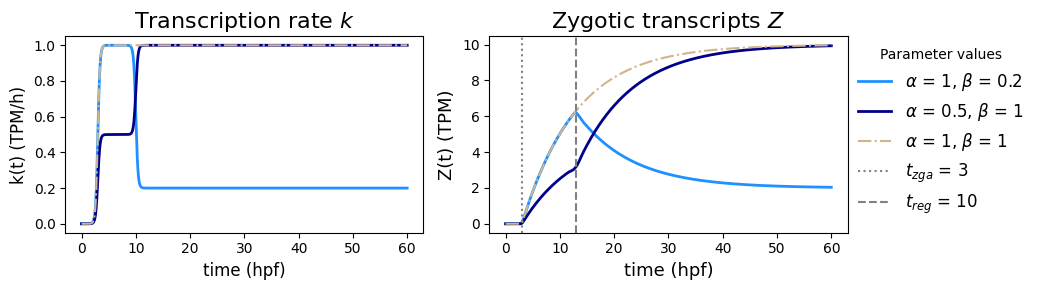

In [1]:
def rep_m(t, y, alpha, beta, delta_z, delta_m, t_zga, dt_rep):
    M, Z = y

    dM_dt = - delta_m * M
    s = 10
    t_rep = t_zga + dt_rep
    on = jax.nn.sigmoid(s * (t - t_zga))
    off =  jax.nn.sigmoid(s * (t - t_rep))

    beta_on = alpha * on * (1 - off) + beta * off
    dZ_dt = beta_on - delta_z * Z

    return dM_dt, dZ_dt

from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import jax

s = 5
s1 = 5
t_zga = 3
t_rep = 10

delta_m = 0.35
delta_z = 0.1

init = (10, 0)
t_end = 60

t = np.linspace(0, t_end, 1000)
on = jax.nn.sigmoid(s * (t - t_zga))
off =  jax.nn.sigmoid(s1 * (t - t_rep))


fig, (ax, ax1) = plt.subplots(1, 2, figsize=(10.5,3))

alpha = 1
beta = 0.2
rate1 = alpha * on * (1 - off) + beta * off
sol1 = solve_ivp(rep_m, (0, t_end), init, t_eval=t, args=(alpha, beta, delta_z, delta_m, t_zga, t_rep))
M, Z = sol1.y
ax.plot(t, rate1, c= "dodgerblue", lw=2, label = f"$\\alpha$ = {alpha}, $\\beta$ = {beta}" )
ax1.plot(sol1.t, Z, c= "dodgerblue", lw=2,label = f"$\\alpha$ = {alpha}, $\\beta$ = {beta}" )

alpha = 0.5
beta = 1
rate2 = alpha * on * (1 - off) + beta * off
ax.plot(t, rate2, c= "darkblue", ls="-", lw=2, label = f"$\\alpha$ = {alpha}, $\\beta$ = {beta}" )
sol2 = solve_ivp(rep_m, (0, t_end), init, t_eval=t, args=(alpha, beta, delta_z, delta_m, t_zga, t_rep))
M, Z = sol2.y
ax1.plot(sol2.t, Z, c= "darkblue", ls="-", lw=2, label = f"$\\alpha$ = {alpha}, $\\beta$ = {beta}" )

alpha = 1
beta = 1
rate2 = alpha * on * (1 - off) + beta * off
ax.plot(t, rate2, c= "tan", ls="-.", label = f"$\\alpha$ = {alpha}, $\\beta$ = {beta}" )
sol2 = solve_ivp(rep_m, (0, t_end), init, t_eval=t, args=(alpha, beta, delta_z, delta_m, t_zga, t_rep))
M, Z = sol2.y
ax1.plot(sol2.t, Z, c= "tan", ls="-.", label = f"$\\alpha$ = {alpha}, $\\beta$ = {beta}" )

ax.set_title( f"Transcription rate $k$", fontsize=16)
ax.set_xlabel("time (hpf)", fontsize=12) 
ax.set_ylabel("k(t) (TPM/h)", fontsize=12)

ax1.set_title(f"Zygotic transcripts $Z$", fontsize=16)
ax1.set_xlabel("time (hpf)", fontsize=13) 
ax1.set_ylabel("Z(t) (TPM)", fontsize=13)

ax1.axvline(x=t_zga, c="grey", ls= ":", label="$t_{zga}$"+f" = {t_zga}")
ax1.axvline(x=t_rep+t_zga,  c="grey", ls= "--", label="$t_{reg}$"+f" = {t_rep}")

#ax.legend()
ax1.legend(loc=(1.01, 0.05), frameon=False, fontsize=12, title="Parameter values")
#plt.suptitle("$\it{Repression}$"+" model")
plt.tight_layout()
plt.savefig("rep_model_rate", dpi=300, transparent=True)